## **RAPPORT STATS DÉCISIONNELS**
*   Yasmine
*   Chaimaa MOURID
*   Juan David GUTIERREZ
*   Rayane Zidoun
*   Jean Philippe







### **1. Préparation des données**

Cette section est dédiée à la préparation et au nettoyage des données brutes issues du fichier `Online Retail.xlsx`.


L'objectif est d'assurer la qualité et la cohérence des données pour les analyses ultérieures. Les étapes clés incluent l'importation des librairies nécessaires, le chargement du dataset, la gestion des valeurs manquantes, la suppression des doublons, le traitement des transactions annulées, et la conversion des types de données pour les colonnes pertinentes, ainsi que la création de nouvelles variables essentielles pour l'analyse.

In [ ]:
#Importation des librairies

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Importation de la base de données

df = pd.read_excel('/content/Online Retail.xlsx')
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#STEP 3: PRÉPARATION ET NETTOYAGE DES DONNÉES

#Visualisation des données manquantes
display(df.isnull().sum())

# Suppression des lignes sans CustomerID
df = df.dropna(subset=["CustomerID"])


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
#Suppression des doublons

#Vérification l'existence de doublons
df.duplicated().sum()

# Suppression des doublons
df = df.drop_duplicates()

In [ ]:
# Suppression des transactions annulées
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

#Vérification du type des variables
display(df.dtypes)

# Conversion en datetime de la variable InvoiceDate
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Conversion en string de la variable CustomerID
df["CustomerID"] = df["CustomerID"].astype("int").astype("str")

# Création de nouvelle colonne
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
print(f"Dimensions après nettoyage : {df.shape}")
print(df.info())
df.head()

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


Dimensions après nettoyage : (392732, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 392732 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392732 non-null  object        
 1   StockCode    392732 non-null  object        
 2   Description  392732 non-null  object        
 3   Quantity     392732 non-null  int64         
 4   InvoiceDate  392732 non-null  datetime64[ns]
 5   UnitPrice    392732 non-null  float64       
 6   CustomerID   392732 non-null  object        
 7   Country      392732 non-null  object        
 8   TotalPrice   392732 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 30.0+ MB
None


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### **2. Analyse Exploratoire des Données**

Cette section vise à explorer et comprendre les caractéristiques principales du jeu de données après nettoyage. Nous allons calculer des indicateurs clés, visualiser les distributions de variables importantes, et identifier les tendances en matière de ventes par pays, par produit et au fil du temps. L'objectif est de dégager des insights préliminaires qui orienteront les analyses plus approfondies.

**2.1. Nb total de commandes, clients et produits**

In [ ]:
# Nombre total de commandes, clients et produits

total_commandes = df['InvoiceNo'].nunique()
total_clients = df['CustomerID'].nunique()
total_produits = df['StockCode'].nunique()

print(f"Commandes: {total_commandes} | Clients: {total_clients} | Produits: {total_produits}")

Commandes: 18536 | Clients: 4339 | Produits: 3665


**2.2. Chiffre d'Affaires par Pays**

,TotalPrice
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


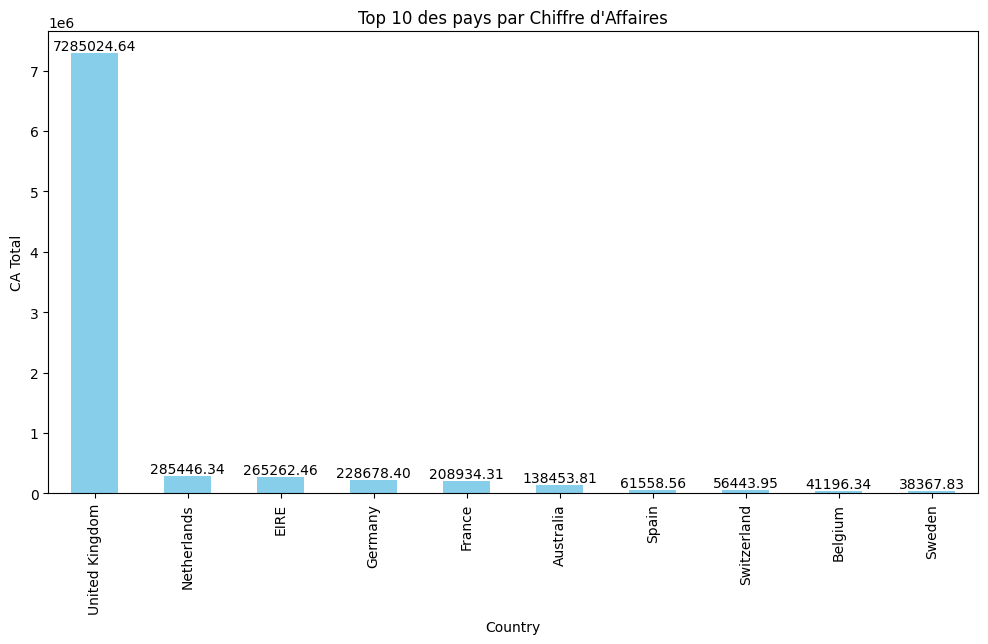

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chiffre d'affaires par pays

# Tableau
sales_country = (df.groupby("Country")["TotalPrice"].sum()
    .sort_values(ascending=False))
display(sales_country.head(10))

# Graphe
ca_par_pays = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = ca_par_pays.plot(kind='bar', color='skyblue')
plt.title('Top 10 des pays par Chiffre d\'Affaires')
plt.ylabel('CA Total')

# Add values on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()



L'analyse du chiffre d'affaires total par pays révèle une forte concentration des ventes. Le **Royaume-Uni** domine largement, générant un chiffre d'affaires de plus de 7,2 millions, ce qui est significativement supérieur à tous les autres pays. Les **Pays-Bas**, l'**EIRE**, l'**Allemagne** et la **France** suivent, mais avec des contributions bien moindres.



**2.3. Top 10 des Produits les Plus Vendus (Quantité)**

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


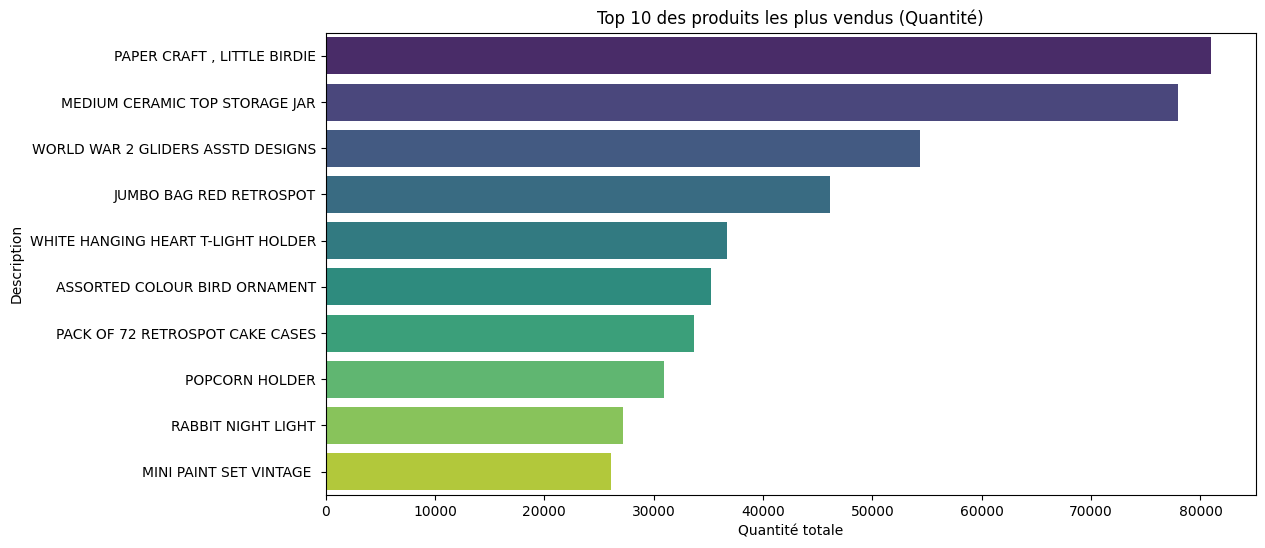

In [ ]:
# TOP 10 DES PRODUITS LES PLUS VENDUS

# Tableau

top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
display(top_products)


# Graphique

top_produits = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_produits.values, y=top_produits.index, palette='viridis', hue=top_produits.index, legend=False)
plt.title('Top 10 des produits les plus vendus (Quantité)')
plt.xlabel('Quantité totale')
plt.show()



Le top 10 des produits les plus vendus, basé sur la quantité, montre une prédominance de quelques articles. Le produit `'PAPER CRAFT , LITTLE BIRDIE'` et `'MEDIUM CERAMIC TOP STORAGE JAR'` sont les plus populaires, avec respectivement 80 995 et 77 916 unités vendues. On observe également des articles variés comme des planeurs, des sacs, et des décorations, indiquant une diversité dans les préférences des clients pour les produits à forte rotation.



**2.4. Analyse de la Saisonnalité**

,TotalPrice
Month,
1,568101.310
2,446084.920
3,594081.760
4,468374.331
5,677355.150
6,660046.050
7,598962.901
8,644051.040
9,950690.202


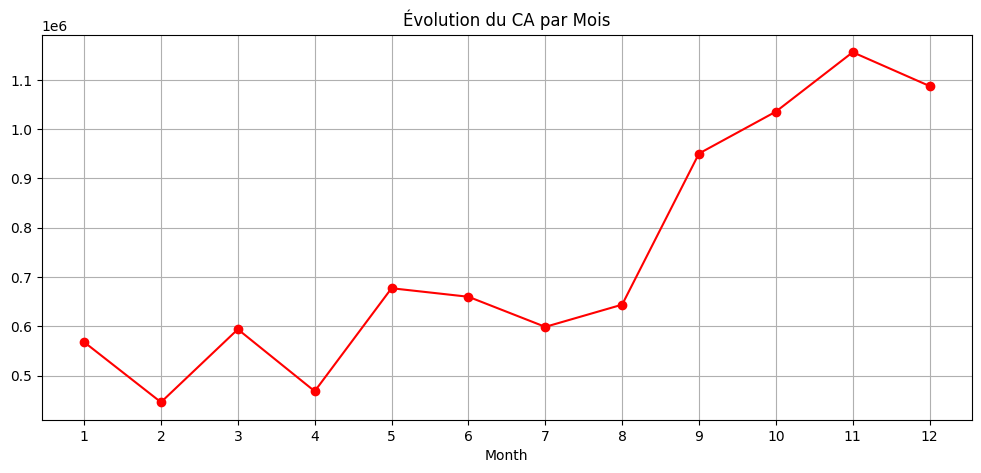

,TotalPrice
Weekday,
Friday,1483080.811
Monday,1363604.401
Sunday,785490.321
Thursday,1973015.730
Tuesday,1697733.801
Wednesday,1584283.830


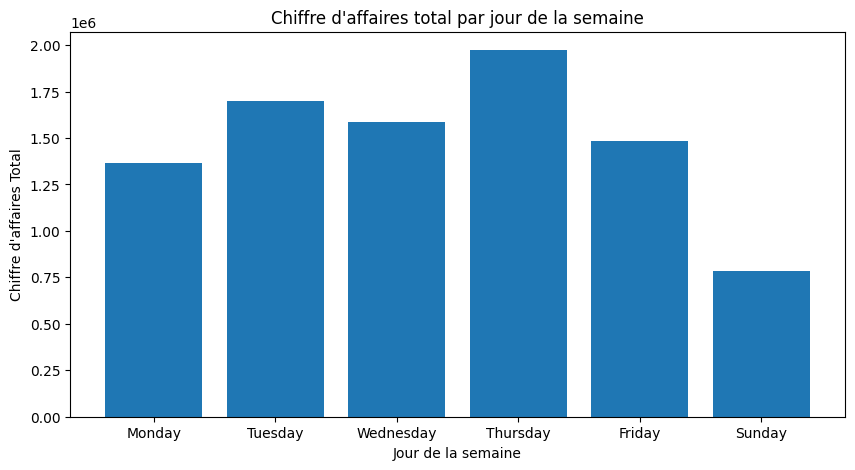

In [ ]:
# Extraction des composants temporels
df['Month'] = df['InvoiceDate'].dt.month
df['Weekday'] = df['InvoiceDate'].dt.day_name()

# Visualisation par mois

sales_month = df.groupby("Month")["TotalPrice"].sum()
display(sales_month)

plt.figure(figsize=(12, 5))
df.groupby('Month')['TotalPrice'].sum().plot(marker='o', color='red')
plt.title('Évolution du CA par Mois')
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

# Visualisation par jour de la semaine

sales_weekday = df.groupby("Weekday")["TotalPrice"].sum()
display(sales_weekday)


ca_weekday = (df.groupby("Weekday")["TotalPrice"].sum().reset_index())
weekday_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]

ca_weekday["Weekday"] = pd.Categorical(ca_weekday["Weekday"],
    categories=weekday_order,
    ordered=True)

ca_weekday = ca_weekday.sort_values("Weekday")


plt.figure(figsize=(10,5))
plt.bar(ca_weekday["Weekday"], ca_weekday["TotalPrice"])
plt.title("Chiffre d'affaires total par jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Chiffre d'affaires Total")
plt.show()



**2.4.1. Évolution du CA par Mois**

L'évolution du chiffre d'affaires par mois révèle une saisonnalité marquée. Les ventes sont généralement plus faibles au début de l'année et augmentent progressivement pour atteindre des pics significatifs en **novembre** et **décembre**. Ce schéma est typique pour les entreprises de commerce de détail, suggérant une forte influence des périodes de fêtes et de fin d'année sur les achats.

**2.4.2. Chiffre d'Affaires par Jour de la Semaine**

L'analyse du chiffre d'affaires par jour de la semaine montre que les **jeudis** et les **mardis** sont les jours les plus lucratifs, avec un chiffre d'affaires total dépassant les 1,6 million chacun. En revanche, les **dimanches** enregistrent le chiffre d'affaires le plus bas, ce qui pourrait s'expliquer par les habitudes d'achat ou les heures d'ouverture réduites si applicable. Cette répartition peut aider à optimiser la planification des opérations et des campagnes marketing.



## **3. Visualisations**

### Évolution du Chiffre d'Affaires Quotidien

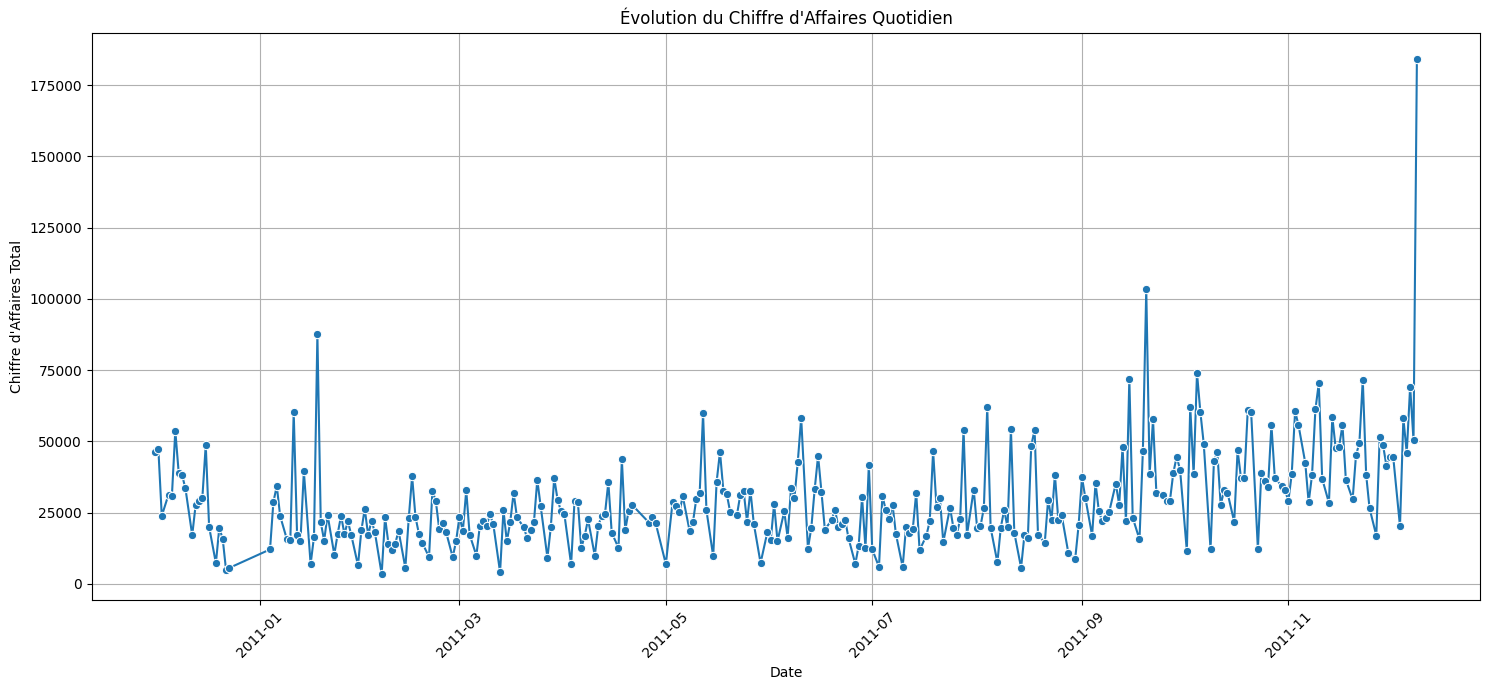

In [ ]:
# Création d'une colonne pour la date uniquement
df['InvoiceDay'] = df['InvoiceDate'].dt.date

# Calcul du chiffre d'affaires quotidien
daily_sales = df.groupby('InvoiceDay')['TotalPrice'].sum().reset_index()

# Visualisation du chiffre d'affaires quotidien
plt.figure(figsize=(15, 7))
sns.lineplot(x='InvoiceDay', y='TotalPrice', data=daily_sales, marker='o', linestyle='-')
plt.title('Évolution du Chiffre d\'Affaires Quotidien')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'Affaires Total')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Analyse : Évolution du Chiffre d'Affaires Quotidien**

Le graphique linéaire montre l'évolution du chiffre d'affaires total par jour. On observe des fluctuations importantes, avec des hauts et des bas tout au long de l'année. Des pics notables de ventes peuvent être identifiés, souvent suivis de périodes plus calmes, ce qui pourrait refléter des événements promotionnels, des jours fériés ou des périodes d'achat saisonnières. La tendance générale sur l'année semble légèrement ascendante vers la fin de la période, avec un pic très élevé en décembre.


### Relation entre Quantité et Prix Unitaire

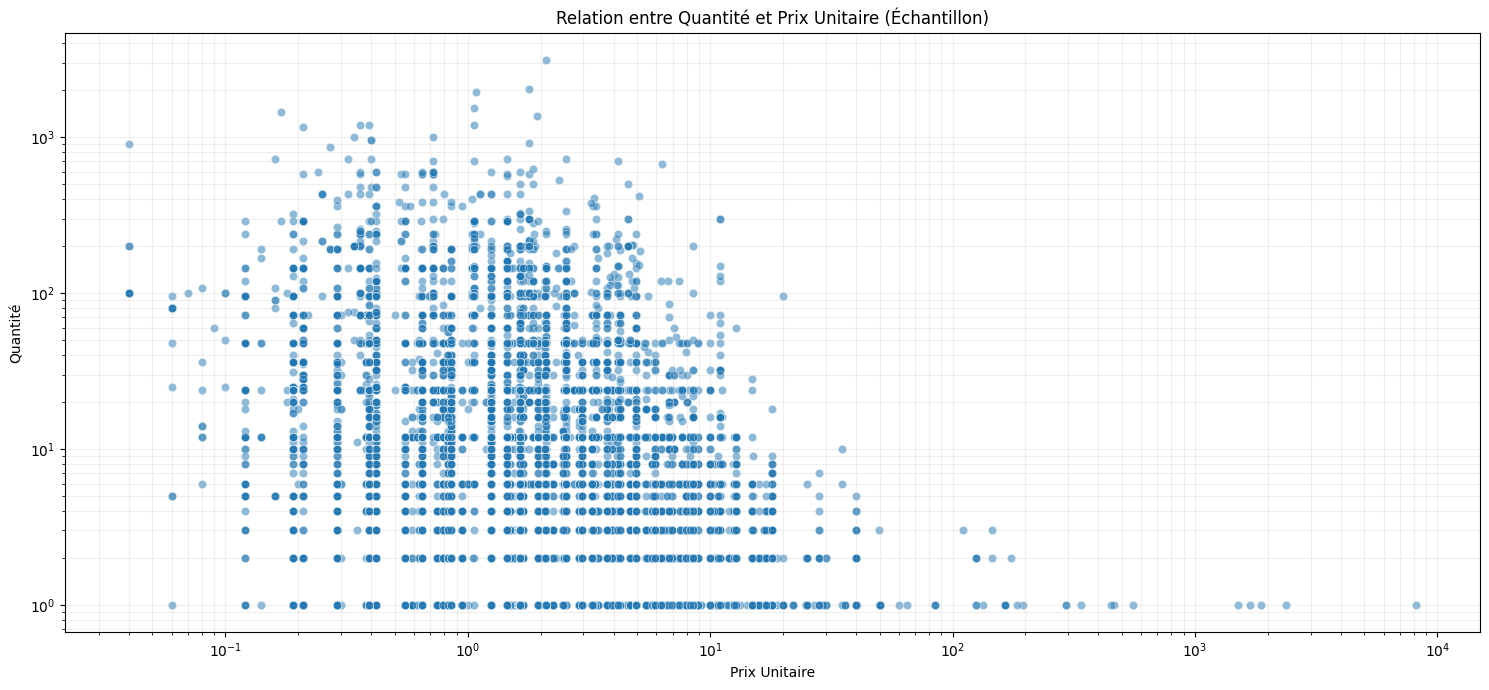

In [ ]:
# Création d'une colonne pour la date uniquement
# Visualisation de la relation entre Quantité et Prix Unitaire

# Nous allons échantillonner les données pour une meilleure visualisation si le DataFrame est trop grand
sample_df = df.sample(n=min(len(df), 50000), random_state=42) # Échantillonner 50 000 lignes ou moins si le df est plus petit

plt.figure(figsize=(15, 7))
sns.scatterplot(x='UnitPrice', y='Quantity', data=sample_df, alpha=0.5)
plt.title('Relation entre Quantité et Prix Unitaire (Échantillon)')
plt.xlabel('Prix Unitaire')
plt.ylabel('Quantité')
plt.xscale('log') # Utilisation d'une échelle logarithmique pour mieux visualiser la distribution des prix
plt.yscale('log') # Utilisation d'une échelle logarithmique pour mieux visualiser la distribution des quantités
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

 **Analyse : Relation entre Quantité et Prix Unitaire**

Ce nuage de points (avec échelles logarithmiques pour une meilleure visualisation) examine la relation entre la quantité de produits achetés et leur prix unitaire. On constate qu'il n'existe pas une forte rélation entre ces deux variables.


### Top 10 des produits par Chiffre d'Affaires

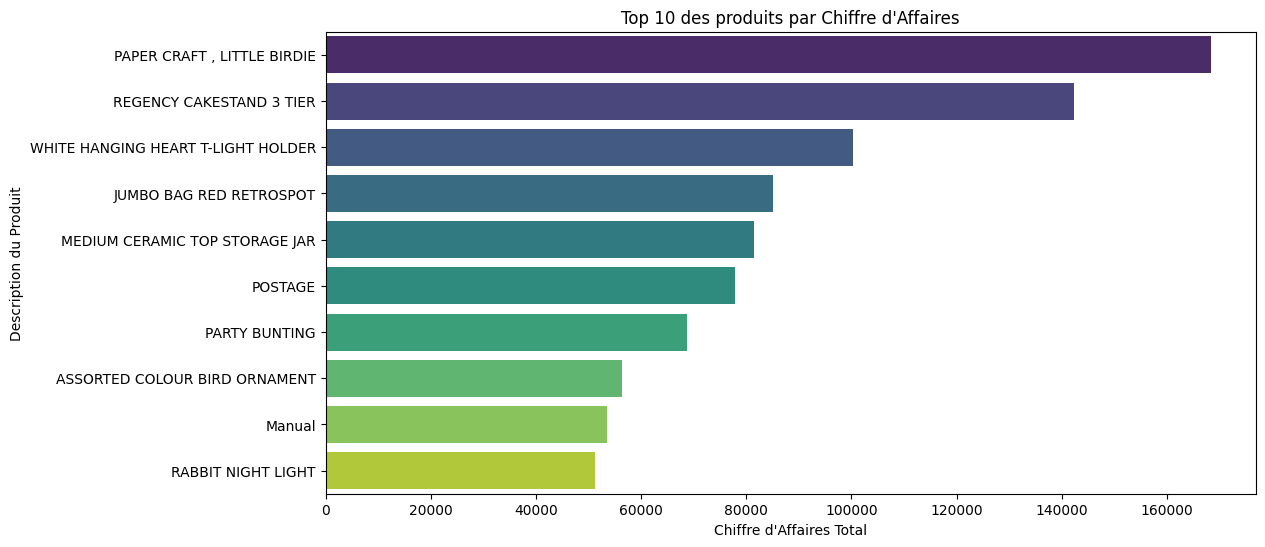

In [ ]:
top_products_ca = (
    df.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products_ca.values, y=top_products_ca.index, palette='viridis', hue=top_products_ca.index, legend=False)
plt.title('Top 10 des produits par Chiffre d\'Affaires')
plt.xlabel('Chiffre d\'Affaires Total')
plt.ylabel('Description du Produit')
plt.show()

**Analyse : Top 10 des produits par Chiffre d'Affaires**

Ce graphique à barres met en évidence les 10 produits générant le plus grand chiffre d'affaires. Contrairement au top des ventes par quantité, ce classement peut inclure des articles moins vendus en volume mais à prix unitaire élevé. On observe que 'PAPER CRAFT , LITTLE BIRDIE' et 'REGENCY CAKESTAND 3 TIER' sont en tête, indiquant qu'ils sont non seulement populaires mais contribuent également fortement aux revenus totaux.


### Heatmap du Chiffre d'Affaires par Jour de la Semaine et Heure

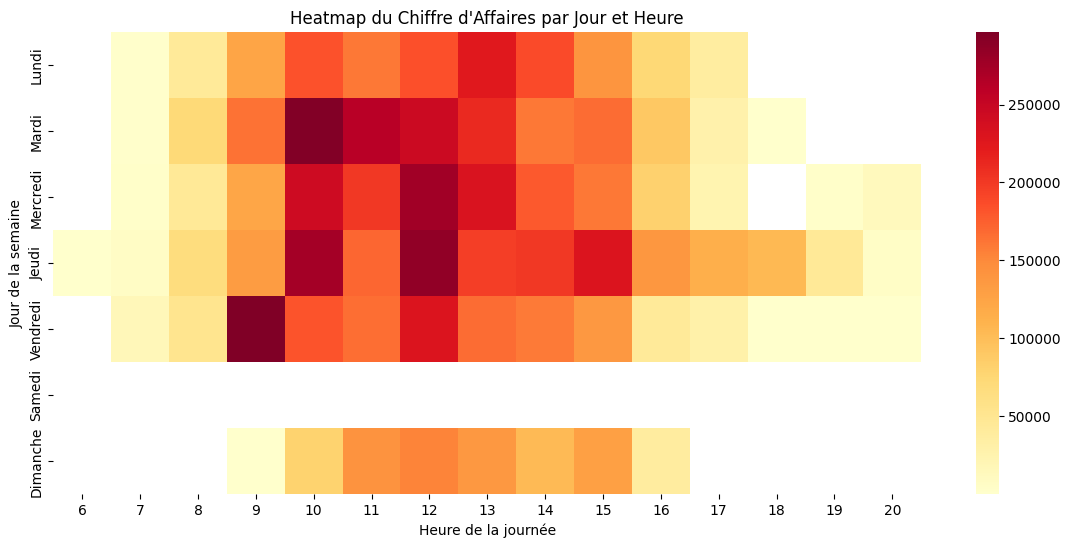

In [ ]:
df["Weekday"] = df["InvoiceDate"].dt.dayofweek
df["Hour"] = df["InvoiceDate"].dt.hour

pivot_hour = df.pivot_table(
    values="TotalPrice",
    index="Weekday",
    columns="Hour",
    aggfunc="sum"
).reindex(range(7), fill_value=pd.NA) # Ensure all weekdays 0-6 are present, fill missing with pd.NA

weekday_labels = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_hour,
    cmap="YlOrRd",
    yticklabels=weekday_labels
)

plt.title("Heatmap du Chiffre d'Affaires par Jour et Heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de la semaine")
plt.show()

**Analyse : Heatmap du Chiffre d'Affaires par Jour de la Semaine et Heure**

Cette heatmap visualise la répartition du chiffre d'affaires par jour de la semaine et par heure de la journée. Les couleurs plus intenses indiquent un chiffre d'affaires plus élevé. On peut observer que les transactions sont majoritairement concentrées en semaine (du lundi au vendredi) et pendant les heures ouvrables, avec des pics vers le milieu de la journée. Les week-ends, en particulier le dimanche, et les heures très tôt le matin ou tard le soir, montrent un chiffre d'affaires bien moindre, voire inexistant.


### Top 10 des clients par CA total


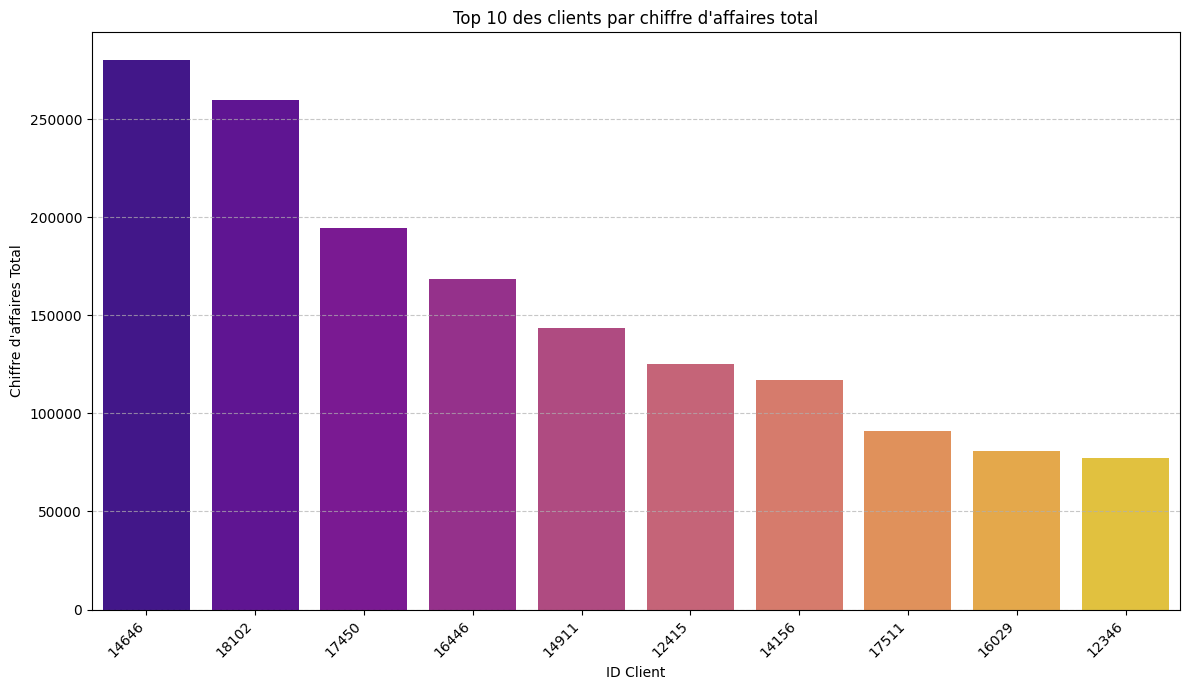

In [ ]:
# Calculer le chiffre d'affaires total par client
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

# Sélectionner les 10 meilleurs clients
top_10_customers = customer_revenue.head(10)

# Créer le graphique à barres
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_customers.index, y=top_10_customers.values, palette='plasma', hue=top_10_customers.index, legend=False)
plt.title('Top 10 des clients par chiffre d\'affaires total')
plt.xlabel('ID Client')
plt.ylabel('Chiffre d\'affaires Total')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 **Analyse : Top 10 des clients par CA total**

Le graphique à barres présente les 10 clients ayant généré le plus grand chiffre d'affaires total pour l'entreprise. Il est clair que quelques clients contribuent de manière significative aux revenus globaux. Le client '14646' se démarque particulièrement avec un chiffre d'affaires de plus de 280 000, suivi par '18102' et '17450'. Ces clients sont extrêmement précieux et devraient faire l'objet de programmes de fidélisation et d'attention particulière pour maintenir et accroître leur engagement.


## **4. Statistiques Descriptives et Analyse de Corrélation**

In [ ]:
# Statistiques descriptives pour les colonnes numériques clés
print("Statistiques descriptives pour Quantity, UnitPrice, TotalPrice:")
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

# Calcul de la variance pour chaque colonne
print("\nVariance pour Quantity, UnitPrice, TotalPrice:")
display(df[['Quantity', 'UnitPrice', 'TotalPrice']].var())

Statistiques descriptives pour Quantity, UnitPrice, TotalPrice:


,Quantity,UnitPrice,TotalPrice
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,22.629195
std,181.588420,22.240725,311.083465
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.390000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000



Variance pour Quantity, UnitPrice, TotalPrice:


,0
Quantity,32974.354130
UnitPrice,494.649861
TotalPrice,96772.922136


**Analyse : Statistiques Descriptives**

Les statistiques descriptives pour `Quantity`, `UnitPrice`, et `TotalPrice` révèlent des informations importantes:
- La **`Quantity`** a une moyenne de 13.06 et une forte variance, indiquant une grande hétérogénéité dans les quantités achetées. Le maximum élevé de 80995 suggère la présence de très grosses commandes, probablement des achats en gros.
- Le **`UnitPrice`** présente une moyenne de 3.12 et une variance modérée. Sa distribution est également large, avec un maximum de 8142.75, ce qui montre une gamme étendue de prix pour les produits.
- Le **`TotalPrice`** a une moyenne de 22.68 et une très grande variance, reflétant la combinaison des variations de quantité et de prix unitaire. Le montant maximum de 168469.60 souligne l'existence de commandes de très grande valeur. Ces indicateurs confirment la nécessité d'une analyse plus approfondie des valeurs extrêmes pour mieux comprendre le comportement d'achat.



Matrice de corrélation entre Quantity, UnitPrice, TotalPrice:


,Quantity,UnitPrice,TotalPrice
Quantity,1.000000,-0.004577,0.908873
UnitPrice,-0.004577,1.000000,0.081620
TotalPrice,0.908873,0.081620,1.000000


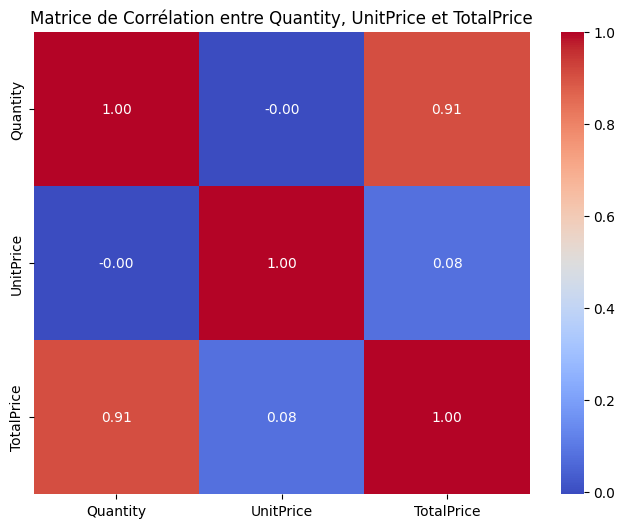

In [ ]:
# Analyse de corrélation entre Quantity, UnitPrice, TotalPrice
print("\nMatrice de corrélation entre Quantity, UnitPrice, TotalPrice:")
correlation_matrix = df[['Quantity', 'UnitPrice', 'TotalPrice']].corr()
display(correlation_matrix)

# Visualisation de la matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation entre Quantity, UnitPrice et TotalPrice')
plt.show()

**Analyse : Matrice de Corrélation**

La matrice de corrélation et sa visualisation sous forme de heatmap nous donnent un aperçu des relations linéaires entre les variables `Quantity`, `UnitPrice` et `TotalPrice` :
- **`Quantity` et `TotalPrice` (0.91) :** Il existe une très forte corrélation positive entre la quantité d'articles achetés et le prix total de la commande. C'est intuitif : plus un client achète d'articles, plus le montant total de sa commande sera élevé. Cette relation est le principal moteur du `TotalPrice`.
- **`UnitPrice` et `TotalPrice` (0.08) :** La corrélation entre le prix unitaire et le prix total est faible mais positive. Cela signifie que les articles plus chers contribuent un peu plus au prix total, mais la quantité a un impact bien plus important.
- **`Quantity` et `UnitPrice` (-0.00) :** La corrélation entre la quantité et le prix unitaire est pratiquement nulle. Cela suggère qu'il n'y a pas de relation linéaire entre le prix d'un article et la quantité que les clients ont tendance à en acheter. Les clients achètent de grandes quantités d'articles à bas prix, ainsi que de petites quantités d'articles à prix élevé, et vice-versa, sans qu'une tendance claire ne se dégage à l'échelle globale.


## **5. Test statistique : ANOVA**

**Hypothèse : "Le montant moyen des commandes diffère selon les pays."**

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Ajuster le modèle ANOVA
model = smf.ols('TotalPrice ~ C(Country)', data=df).fit()

# Réaliser le test ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

# Afficher le tableau ANOVA
display(anova_table)

,sum_sq,df,F,PR(>F)
C(Country),4.248660e+07,36.0,12.207917,8.104939e-71
Residual,3.796324e+10,392695.0,NaN,NaN


**Interprétation du résultat**

La p-value obtenue pour 'C(Country)' est 8.104939e-71. Cette valeur est extrêmement faible, bien inférieure au seuil de signification couramment utilisé de 0.05.

**Interprétation** : Étant donné que la p-value (8.104939e-71) est inférieure à 0.05, nous rejetons l'hypothèse nulle. Cela signifie qu'il existe une différence significative dans le montant moyen des commandes entre les différents pays. En d'autres termes, les ventes moyennes par commande ne sont pas les mêmes pour tous les pays inclus dans l'analyse.



## **6. Régression Linéaire Multiple**

**Objectif :** Modéliser le `TotalPrice` en fonction de `Quantity`, `UnitPrice`, du jour de la semaine et du pays.

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model_mlr = smf.ols('TotalPrice ~ Quantity + UnitPrice + C(Country) + C(Weekday)', data=df).fit()

# Afficher le résumé du modèle
model_mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TotalPrice   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                 4.570e+04
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:28:53   Log-Likelihood:            -2.4596e+06
No. Observations:              392732   AIC:                         4.919e+06
Df Residuals:                  392688   BIC:                         4.920e+06
Df Model:                          43                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                              4.2248      3.732      1.132      0.258      -3.089      11.539
C(Country)[T.Austria]                 -1.3290      7.359     -0.181      0.857     -15.753      13.095
C(Country)[T.Bahrain]                  0.1122     31.015      0.004      0.997     -60.676      60.901
C(Country)[T.Belgium]                 -4.7212      4.644     -1.017      0.309     -13.823       4.381
C(Country)[T.Brazil]                   8.8335     22.751      0.388      0.698     -35.759      53.426
C(Country)[T.Canada]                 -14.2486     10.983     -1.297      0.195     -35.774       7.277
C(Country)[T.Channel Islands]         -0.4140      5.933     -0.070      0.944     -12.043      11.215
C(Country)[T.Cyprus]                  -3.8573      6.354     -0.607      0.544     -16.311       8.596
C(Country)[T.Czech Republic]         -15.8655     25.662     -0.618      0.536     -66.161      34.430
C(Country)[T.Denmark]                  9.8756      7.487      1.319      0.187      -4.799      24.550
C(Country)[T.EIRE]                    -1.6816      3.983     -0.422      0.673      -9.489       6.125
C(Country)[T.European Community]       0.4980     16.802      0.030      0.976     -32.433      33.429
C(Country)[T.Finland]                 -0.4513      6.096     -0.074      0.941     -12.399      11.496
C(Country)[T.France]                  -3.7608      3.945     -0.953      0.340     -11.493       3.972
C(Country)[T.Germany]                 -2.4814      3.927     -0.632      0.527     -10.178       5.215
C(Country)[T.Greece]                   7.3532     11.175      0.658      0.511     -14.549      29.255
C(Country)[T.Iceland]                 -2.9916     10.109     -0.296      0.767     -22.806      16.822
C(Country)[T.Israel]                  -3.2062      8.915     -0.360      0.719     -20.678      14.266
C(Country)[T.Italy]                   -2.1961      5.908     -0.372      0.710     -13.776       9.383
C(Country)[T.Japan]                  -14.6277      7.991     -1.831      0.067     -30.289       1.034
C(Country)[T.Lebanon]                 15.2054     19.286      0.788      0.430     -22.594      53.005
C(Country)[T.Lithuania]               13.0083     21.781      0.597      0.550     -29.682      55.699
C(Country)[T.Malta]                    2.6420     12.554      0.210      0.833     -21.964      27.248
C(Country)[T.Netherlands]            -17.5740      4.521     -3.887      0.000     -26.436      -8.712
C(Country)[T.Norway]                  -3.6565      5.356     -0.683      0.495     -14.154       6.841
C(Country)[T.Poland]                  -2.7589      7.905     -0.349      0.727     -18.252      12.734
C(Country)[T.Portugal]                -4.0429      4.972     -0.813      0.416     -13.787      

 **Interprétation des Résultats de la Régression Linéaire Multiple**

Le modèle explique 83.3% de la variation de la variable Total Price, principalement grâce à la variable Quantity et la variable Unit Price, qui sont des prédicteurs très forts et statistiquement significatifs.

L'impact du pays est variable et souvent non significatif pour de nombreux pays par rapport au prix total.

L'impact du jour de la semaine est majoritairement non significatif. Le problème de multicolinéarité doit être pris en compte lors de l'interprétation des coefficients, en particulier si l'objectif est de comprendre l'impact isolé de chaque variable.

## **7. Préparation des Données pour la Segmentation Client (RFM)**

**7.1. Construction d'indicateurs client**

In [ ]:
# Calcul de la récence
# Déterminer la date maximale dans l'ensemble de données (date de référence)
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1) # Ajouter un jour pour avoir un point de référence futur

# Calculer la date de la dernière commande pour chaque client
recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()
recency_df['Recency'] = (current_date - recency_df['InvoiceDate']).dt.days

# Calcul du montant total dépensé
monetary_df = df.groupby('CustomerID')['TotalPrice'].sum().reset_index()
monetary_df.rename(columns={'TotalPrice': 'Monetary'}, inplace=True)

# Calcul du nombre total d'achats
frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
frequency_df.rename(columns={'InvoiceNo': 'Frequency'}, inplace=True)

# Calcul de la quantité totale achetée
quantity_df = df.groupby('CustomerID')['Quantity'].sum().reset_index()
quantity_df.rename(columns={'Quantity': 'Quantity_Total'}, inplace=True)

# Fusionner tous les indicateurs
rfm_df = recency_df[['CustomerID', 'Recency']].merge(frequency_df, on='CustomerID')
rfm_df = rfm_df.merge(monetary_df, on='CustomerID')
rfm_df = rfm_df.merge(quantity_df, on='CustomerID')

display(rfm_df.head())
print(f"Dimensions du DataFrame RFM : {rfm_df.shape}")

,CustomerID,Recency,Frequency,Monetary,Quantity_Total
0,12346,326,1,77183.60,74215
1,12347,2,7,4310.00,2458
2,12348,75,4,1797.24,2341
3,12349,19,1,1757.55,631
4,12350,310,1,334.40,197


Dimensions du DataFrame RFM : (4339, 5)


**Standardisation des variables pour le clustering (Z-score)**

In [ ]:
from sklearn.preprocessing import StandardScaler

# Sélection des colonnes à standardiser
features_to_scale = ['Recency', 'Frequency', 'Monetary', 'Quantity_Total']

# Initialisation du StandardScaler
scaler = StandardScaler()

# Application de la standardisation
rfm_scaled = scaler.fit_transform(rfm_df[features_to_scale])

# Création d'un nouveau DataFrame avec les valeurs standardisées
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features_to_scale, index=rfm_df.index)

display(rfm_scaled_df.head())
print(f"Statistiques descriptives des variables standardisées :\n{rfm_scaled_df.describe()}")

,Recency,Frequency,Monetary,Quantity_Total
0,2.334858,-0.424675,8.363977,14.452940
1,-0.905199,0.354080,0.251779,0.250849
2,-0.175186,-0.035297,-0.027938,0.227692
3,-0.735196,-0.424675,-0.032357,-0.110750
4,2.174855,-0.424675,-0.190780,-0.196647


Statistiques descriptives des variables standardisées :
            Recency     Frequency      Monetary  Quantity_Total
count  4.339000e+03  4.339000e+03  4.339000e+03    4.339000e+03
mean   7.532834e-17  1.965087e-17 -4.585203e-17    2.292602e-17
std    1.000115e+00  1.000115e+00  1.000115e+00    1.000115e+00
min   -9.151995e-01 -4.246749e-01 -2.280048e-01   -2.354389e-01
25%   -7.451965e-01 -4.246749e-01 -1.938906e-01   -2.041677e-01
50%   -4.151906e-01 -2.948824e-01 -1.535816e-01   -1.608234e-01
75%    4.948256e-01  9.449517e-02 -4.318064e-02   -3.959783e-02
max    2.814867e+00  2.670196e+01  3.096418e+01    3.885163e+01


**7.2. Segmentation par K-means**

Nous allons appliquer l'algorithme K-means sur les données client standardisées (`rfm_scaled_df`). L'objectif est de regrouper les clients en segments homogènes basés sur leurs comportements d'achat (Récence, Fréquence, Monétaire, Quantité Totale).

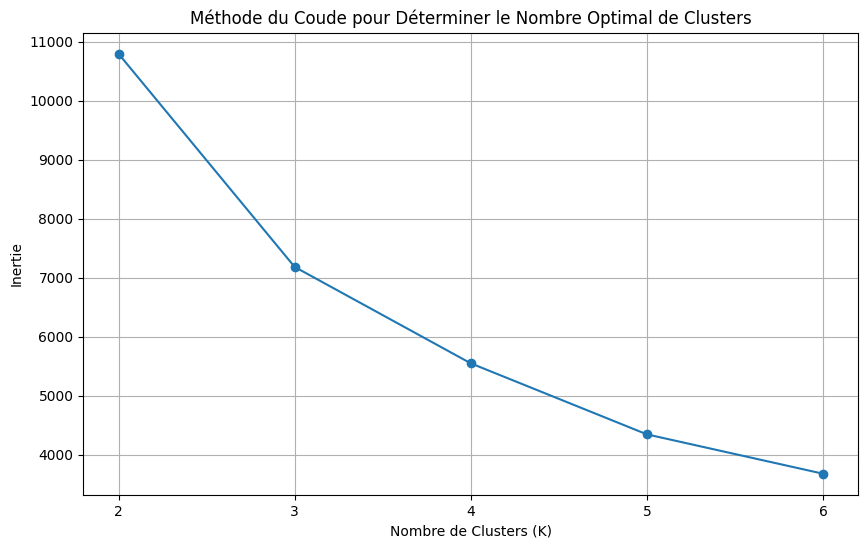

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Liste pour stocker les valeurs d'inertie
inertia = []

# Définir la plage de clusters à tester (de 2 à 6)
clusters_range = range(2, 7)

# Appliquer K-means pour chaque nombre de clusters et enregistrer l'inertie
for k in clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init pour éviter les avertissements
    kmeans.fit(rfm_scaled_df)
    inertia.append(kmeans.inertia_)

# Visualisation de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(clusters_range, inertia, marker='o')
plt.title('Méthode du Coude pour Déterminer le Nombre Optimal de Clusters')
plt.xlabel('Nombre de Clusters (K)')
plt.ylabel('Inertie')
plt.xticks(clusters_range)
plt.grid(True)
plt.show()

**Choix du Nombre de Clusters (Méthode du Coude)**

Le graphique ci-dessus montre l'inertie (somme des carrés des distances des points à leur centroïde le plus proche) en fonction du nombre de clusters. L'idée de la méthode du coude est de choisir le nombre de clusters K où la diminution de l'inertie commence à ralentir de manière significative, formant ainsi un 'coude'.

Observons le graphique pour identifier ce point. Un K de 3 ou 4 semble être un bon compromis pour notre jeu de données. Pour la suite, on va choisir 4 clusters.

In [ ]:
# Appliquer K-means avec le nombre de clusters choisi (par exemple, 4)
k_chosen = 4 # Peut être modifié en fonction de l'observation du coude
kmeans_final = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
kmeans_final.fit(rfm_scaled_df)

# Attribuer le numéro de cluster à chaque client dans le DataFrame RFM original
rfm_df['Cluster'] = kmeans_final.labels_

# Afficher les premières lignes du DataFrame RFM avec les clusters attribués
display(rfm_df.head())

# Afficher la distribution des clients par cluster
print("Distribution des clients par cluster :\n", rfm_df['Cluster'].value_counts())

,CustomerID,Recency,Frequency,Monetary,Quantity_Total,Cluster
0,12346,326,1,77183.60,74215,1
1,12347,2,7,4310.00,2458,0
2,12348,75,4,1797.24,2341,0
3,12349,19,1,1757.55,631,0
4,12350,310,1,334.40,197,2


Distribution des clients par cluster :
 Cluster
0    3203
2    1080
3      47
1       9
Name: count, dtype: int64


**7.3. Profiling des segments**

Nous allons maintenant caractériser chaque segment client en examinant les statistiques descriptives de leurs indicateurs RFM, puis visualiser ces profils à l'aide de boxplots.

In [ ]:
# Calculer les moyennes des indicateurs RFM pour chaque cluster
cluster_profiles = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Quantity_Total']].mean()
display(cluster_profiles)

# Calculer les médianes des indicateurs RFM pour chaque cluster
print("\nMédianes des indicateurs RFM par cluster :")
cluster_medians = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary', 'Quantity_Total']].median()
display(cluster_medians)

,Recency,Frequency,Monetary,Quantity_Total
Cluster,,,,
0,41.797377,4.444583,1667.049523,988.998751
1,41.777778,54.555556,161867.596667,85253.000000
2,247.129630,1.582407,559.045631,283.063889
3,6.042553,44.680851,31639.821702,19683.765957



Médianes des indicateurs RFM par cluster :


,Recency,Frequency,Monetary,Quantity_Total
Cluster,,,,
0,31.0,3.0,899.69,520.0
1,3.0,46.0,143711.17,74215.0
2,242.0,1.0,310.16,152.0
3,4.0,34.0,28117.04,15968.0


**Visualisation des profils de clusters avec des Boxplots**

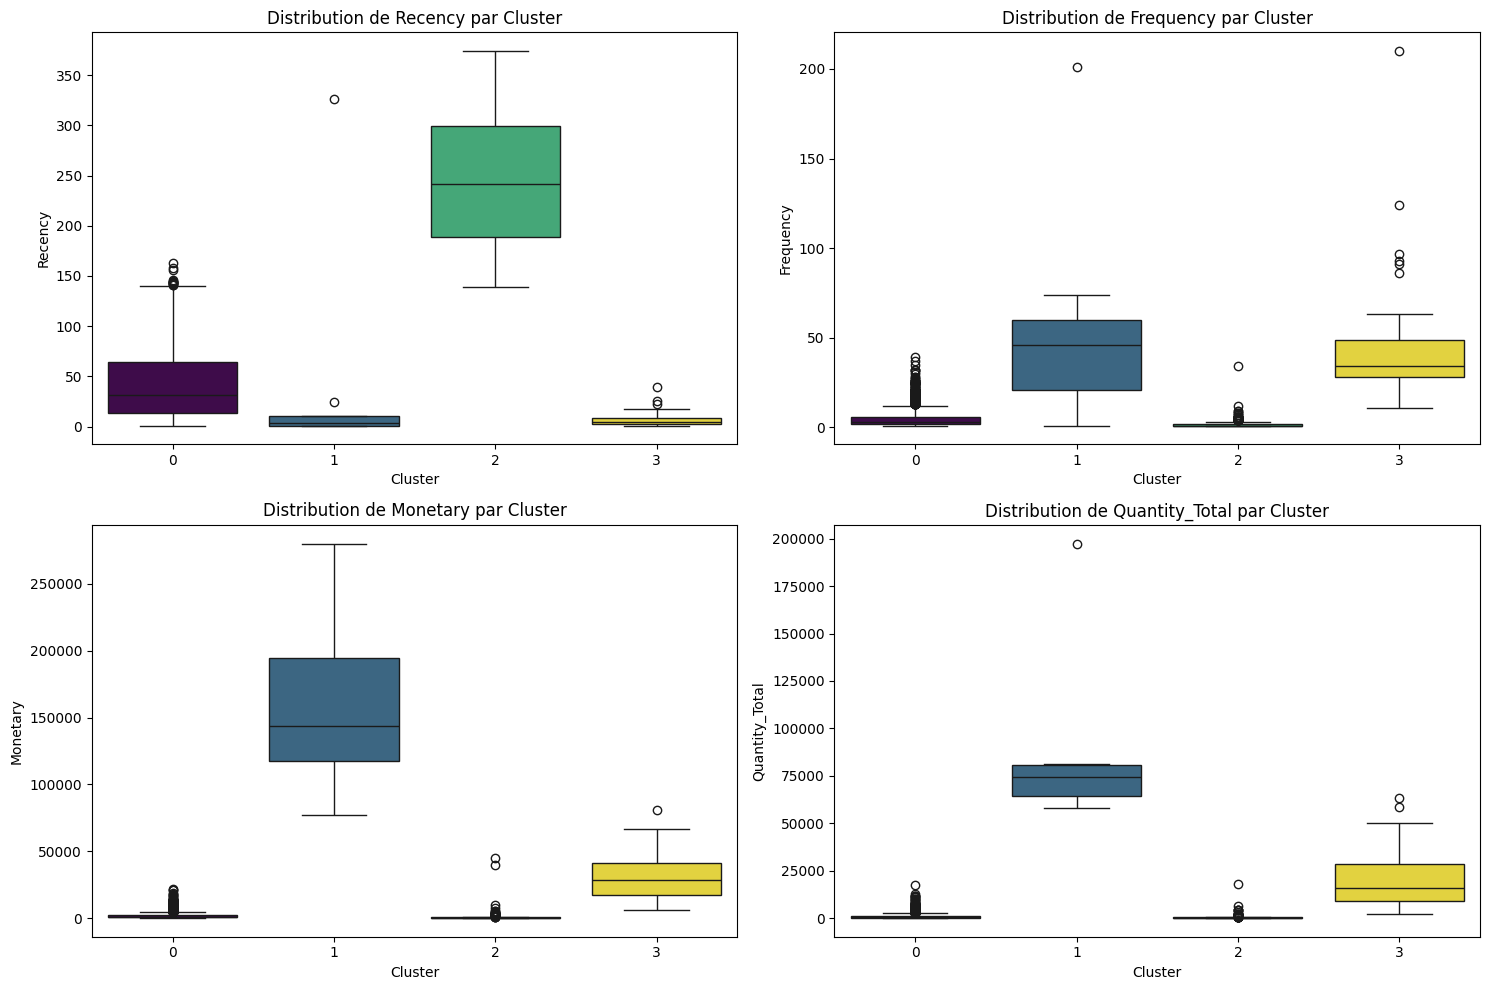

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

metrics = ['Recency', 'Frequency', 'Monetary', 'Quantity_Total']

for i, metric in enumerate(metrics):
    sns.boxplot(x='Cluster', y=metric, data=rfm_df, ax=axes[i], palette='viridis', hue='Cluster', legend=False)
    axes[i].set_title(f'Distribution de {metric} par Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

**7.4. Interprétation Marketing et Actions (Data-Driven)**

**Synthèse des Clusters Clients :**

*   **Cluster 1 (Clients Champions):** Ce segment représente les clients les plus précieux. Ils ont une très faible récence (achats récents), une fréquence d'achat très élevée, et un montant monétaire ainsi qu'une quantité totale achetée extrêmement élevés. Ce sont les piliers du chiffre d'affaires.

*   **Cluster 3 (Clients Fidèles):** Ces clients sont également très engagés. Ils présentent une faible récence, une fréquence et un montant monétaire élevés, ainsi qu'une quantité totale achetée importante. Ils sont récents et contribuent significativement aux revenus.

*   **Cluster 0 (Clients Moyens):** C'est le plus grand groupe de clients, avec des valeurs modérées pour la récence, la fréquence, le montant monétaire et la quantité totale. Ils représentent la base de la clientèle.

*   **Cluster 2 (Clients à Risque):** Ce segment est caractérisé par une récence très élevée (n'a pas acheté depuis longtemps), une faible fréquence d'achat et un faible montant monétaire. Ce sont des clients qui risquent de ne plus acheter ou qui ont déjà cessé de le faire.

**Actions Marketing Recommandées :**

1.  **Pour les Clients Champions (Cluster 1) et Fidèles (Cluster 3) :**
    *   **Action :** Mettre en place des programmes de fidélité VIP, des offres exclusives personnalisées, des avant-premières sur les nouveaux produits, et des communications pour recueillir leurs avis et suggestions. Accorder un service client premium.
    *   **Justification :** Ces clients génèrent la majorité des revenus et sont les plus engagés. Il est crucial de les chouchouter, de les reconnaître pour leur valeur et de renforcer leur fidélité pour maximiser leur valeur vie client (CLTV).

2.  **Pour les Clients Moyens (Cluster 0) :**
    *   **Action :** Lancer des campagnes de cross-selling et d'up-selling basées sur l'historique d'achat, des promotions ciblées pour augmenter la fréquence d'achat (ex: "-10% sur votre prochaine commande si effectuée dans les 30 jours"), ou des recommandations de produits complémentaires.
    *   **Justification :** Ce large segment a un potentiel de croissance. L'objectif est de les faire évoluer vers les segments plus rentables en augmentant leur fréquence et leur valeur moyenne d'achat.

3.  **Pour les Clients à Risque (Cluster 2) :**
    *   **Action :** Mettre en œuvre des campagnes de réactivation avec des incitations fortes (ex: "-20% pour votre retour"), des enquêtes de satisfaction pour comprendre les raisons de leur inactivité, et des recommandations de produits personnalisées.
    *   **Justification :** Ces clients sont sur le point de, ou ont déjà, déserté. Une approche ciblée peut les ramener et réduire le taux de désabonnement, qui coûte plus cher que l'acquisition de nouveaux clients.

**7.5. Questions de synthèse**



**Quels indicateurs ont le plus influencé la segmentation ? Pourquoi ?**

Les indicateurs qui ont le plus influencé la segmentation sont la Fréquence (Frequency), le Montant Monétaire (Monetary) et la Quantité Totale (Quantity_Total). La Récence (Recency) a également joué un rôle crucial, notamment pour identifier les clients à risque.

Les clusters de forte valeur (Cluster 1 et 3) se distinguent par des valeurs exceptionnellement élevées pour la fréquence, le montant et la quantité, tandis que le Cluster 2 (clients à risque) est clairement défini par une récence très élevée (faible activité récente).


**Quel cluster semble le plus stratégique commercialement ?**

Le Cluster 1 est le plus stratégique commercialement. Bien qu'il soit plus petit en nombre, il représente les clients qui ont les récence, fréquence, montant monétaire et quantité totale les plus élevés. Ce sont les clients qui génèrent le plus de revenus et démontrent la plus grande fidélité. Le Cluster 3 est également très stratégique et représente des clients fidèles et récents à haute valeur.


**Proposez deux actions marketing basées sur vos résultats.**


**Action 1** (Ciblant les Clusters 1 et 3) : Mettre en place un programme de fidélité VIP avec des offres exclusives, des avant-premières sur les nouveaux produits et un service client premium. L'objectif est de renforcer leur engagement et de maximiser leur valeur vie client (CLTV).


**Action 2** (Ciblant le Cluster 2 - Clients à Risque) : Lancer des campagnes de réactivation ciblées avec des incitations fortes (ex: "-20% pour votre prochaine commande") et des enquêtes pour comprendre les raisons de leur inactivité. L'objectif est de réduire le taux de désabonnement en ramenant ces clients vers des segments plus actifs.